In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv("Exam_Score_Prediction.csv")
print(df.head())

   student_id  age  gender   course  study_hours  class_attendance  \
0           1   17    male  diploma         2.78              92.9   
1           2   23   other      bca         3.37              64.8   
2           3   22    male     b.sc         7.88              76.8   
3           4   20   other  diploma         0.67              48.4   
4           5   20  female  diploma         0.89              71.6   

  internet_access  sleep_hours sleep_quality   study_method facility_rating  \
0             yes          7.4          poor       coaching             low   
1             yes          4.6       average  online videos          medium   
2             yes          8.5          poor       coaching            high   
3             yes          5.8       average  online videos             low   
4             yes          9.8          poor       coaching             low   

  exam_difficulty  exam_score  
0            hard        58.9  
1        moderate        54.8  
2       

In [8]:
# we have -> y=mx + b where y(score) and x(study_hours) and our goal is find as much as possible near m and b
# for that we have MSE(mean squared error) equation with using differential equation on top of that we can find direction whether go up or down
# E = MEAN(actual_y - (mx + b)^2)
# here is differential_equations
# E(m)' = 2 * MEAN(-x)(actual_y - (mx + b))
# E(b)' = 2 * MEAN(actual_y - (mx + b))
def loss(m, b, x_values, y_values):
    return np.mean([(y - (m * x + b))**2 for x, y in zip(x_values, y_values)])

def differential_m_loss(m: int, b: int, x_values: list[int], y_values: list[int]) -> int:
    return -2 * np.mean([x * (y - (m * x + b)) for x, y in zip(x_values, y_values)])

def differential_b_loss(m: int, b: int, x_values: list[int], y_values: list[int]) -> int:
    return -2 * np.mean([(y - (m * x + b)) for x, y in zip(x_values, y_values)])

In [25]:
L = 0.01 # learning rate with simple words length of steps
ITERATION_COUNT = 4000

x_values = df["study_hours"].tolist()
print(x_values)

y_values = df["exam_score"].tolist()
print(y_values)

[2.78, 3.37, 7.88, 0.67, 0.89, 3.48, 1.35, 5.48, 2.89, 6.77, 5.99, 3.77, 6.76, 0.81, 4.65, 4.84, 1.97, 0.4, 4.28, 4.11, 5.23, 1.7, 1.44, 7.82, 0.91, 7.91, 5.76, 5.03, 2.72, 6.94, 7.28, 5.78, 5.68, 3.95, 0.62, 7.91, 0.12, 3.96, 2.94, 6.21, 5.89, 5.02, 0.6, 1.89, 0.75, 7.83, 1.02, 7.74, 0.9, 6.9, 4.6, 6.65, 5.07, 6.15, 5.85, 2.08, 7.48, 5.15, 1.62, 2.45, 4.26, 7.05, 6.37, 2.42, 5.51, 0.08, 2.66, 6.72, 1.21, 2.83, 0.08, 0.19, 1.17, 0.81, 3.92, 7.2, 0.68, 6.96, 5.35, 1.35, 2.32, 1.55, 6.31, 5.8, 2.44, 0.43, 1.35, 5.04, 0.72, 4.29, 4.9, 5.5, 1.0, 3.68, 3.71, 6.68, 3.75, 3.25, 0.99, 5.56, 4.96, 5.74, 5.25, 7.0, 7.02, 2.46, 1.46, 7.41, 5.7, 7.77, 3.98, 7.7, 0.98, 4.72, 3.97, 0.08, 1.54, 1.23, 0.49, 7.59, 7.72, 7.13, 7.91, 6.65, 7.46, 1.58, 2.06, 6.9, 3.84, 5.74, 4.5, 2.45, 2.28, 5.99, 4.26, 2.88, 4.94, 3.36, 3.8, 5.42, 3.66, 7.6, 3.88, 7.69, 6.78, 7.13, 6.11, 4.84, 4.26, 4.41, 1.61, 1.72, 0.27, 5.96, 1.0, 4.66, 1.1, 0.53, 4.27, 6.98, 2.85, 7.35, 0.08, 3.73, 1.17, 2.53, 0.19, 0.28, 5.7, 5.24, 

In [26]:
m, b = 0.0, 0.0

for i in range(ITERATION_COUNT):
    dm = differential_m_loss(m=m, b=b, x_values=x_values, y_values=y_values)
    db = differential_b_loss(m=m, b=b, x_values=x_values, y_values=y_values)

    m = m - L * dm
    b = b - L * db

    current_loss = loss(m, b, x_values, y_values)

    if i % 100 == 0:
        print(i, "loss =", current_loss)

    if current_loss < 0.0001:
        print("Stopped early at iteration", i)
        break

error = loss(m, b, x_values, y_values)

print("m =", m)
print("b =", b)
print("error =", error)

0 loss = 1669.1247270061886
100 loss = 298.8037586975088
200 loss = 221.14500453333395
300 loss = 191.54553502912702
400 loss = 180.26375998186975
500 loss = 175.96373534126505
600 loss = 174.32479006604416
700 loss = 173.7001095491457
800 loss = 173.46201389452423
900 loss = 173.37126424055538
1000 loss = 173.33667520234482
1100 loss = 173.32349166376358
1200 loss = 173.318466785984
1300 loss = 173.3165515644716
1400 loss = 173.31582158185265
1500 loss = 173.31554335052505
1600 loss = 173.31543730324444
1700 loss = 173.31539688354826
1800 loss = 173.3153814776668
1900 loss = 173.31537560574768
2000 loss = 173.31537336767818
2100 loss = 173.31537251464272
2200 loss = 173.3153721895101
2300 loss = 173.31537206558644
2400 loss = 173.31537201835323
2500 loss = 173.3153720003504
2600 loss = 173.31537199348867
2700 loss = 173.31537199087333
2800 loss = 173.3153719898765
2900 loss = 173.31537198949655
3000 loss = 173.31537198935175
3100 loss = 173.31537198929655
3200 loss = 173.3153719892755

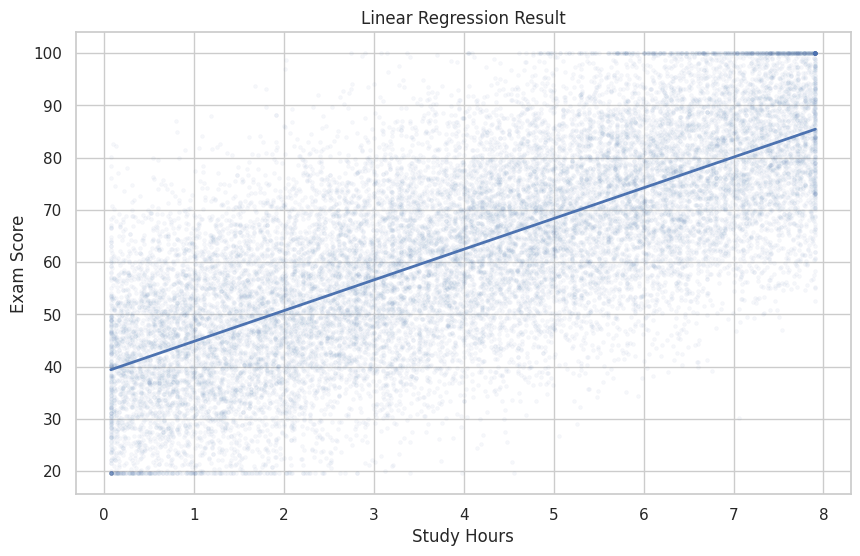

In [33]:
x = np.array(x_values, dtype=float)
y = np.array(y_values, dtype=float)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))
sns.scatterplot(x=x_values, y=y_values, s=8, alpha=0.05, edgecolor=None)

# твоя линия
x_line = np.linspace(min(x_values), max(x_values), 200)
plt.plot(x_line, m * x_line + b, linewidth=2)

plt.title("Linear Regression Result")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.show()